In [ ]:
#Import Libraries

!pip install imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("creditcard.csv")


In [ ]:
print("First Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

First Five Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26     

In [ ]:
print("Missing Values\n")

print(df.isnull().sum())

Missing Values

Time      0
V1        1
V2        1
V3        1
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
print("Number of Transactions :", len(df))
print("Number of Features :", df.shape[1]-1)
print("Target Variable : Class")
print("0 = Genuine Transaction")
print("1 = Fraudulent Transaction")

Number of Transactions : 27819
Number of Features : 30
Target Variable : Class
0 = Genuine Transaction
1 = Fraudulent Transaction


In [ ]:
print(df["Class"].value_counts())

print("\nPercentage Distribution")

print(df["Class"].value_counts(normalize=True)*100)

Class
0.0    27725
1.0       93
Name: count, dtype: int64

Percentage Distribution
Class
0.0    99.665684
1.0     0.334316
Name: proportion, dtype: float64


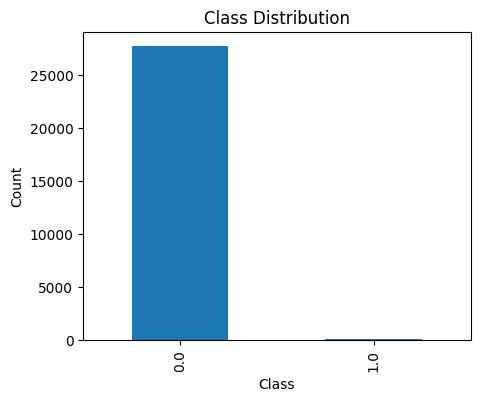

In [ ]:
plt.figure(figsize=(5,4))

df["Class"].value_counts().plot(kind='bar')

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [ ]:
df = df.dropna()

print(df.isnull().sum())

X = df.drop("Class", axis=1)

y = df["Class"]

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Training Set :", X_train.shape)

print("Validation Set :", X_val.shape)

print("Testing Set :", X_test.shape)

Training Set : (22254, 30)
Validation Set : (2782, 30)
Testing Set : (2782, 30)


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

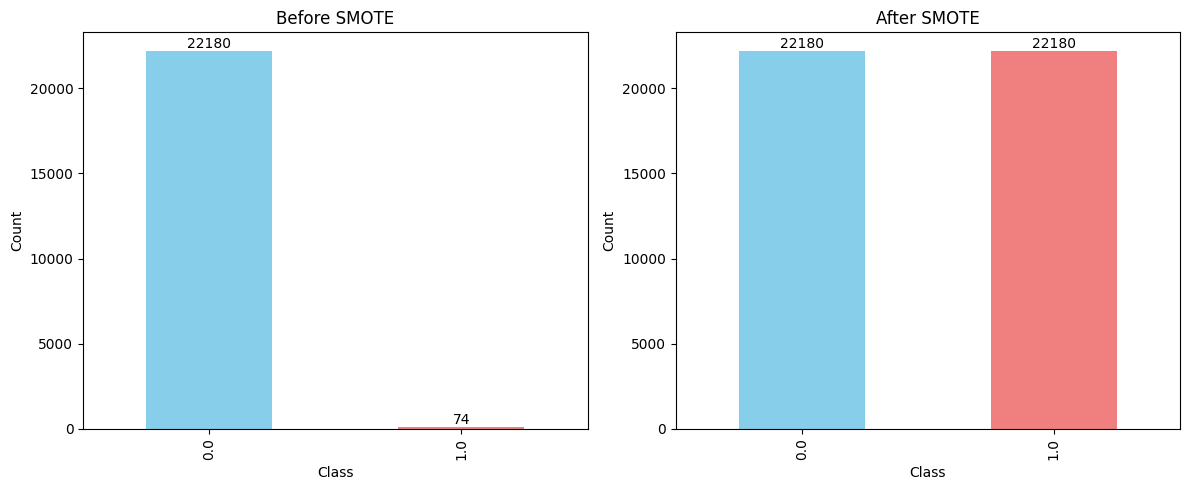

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

before = y_train.value_counts()
after = y_train_smote.value_counts()

before.plot(kind='bar', color=['skyblue','lightcoral'], ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

for i, v in enumerate(before):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

after.plot(kind='bar', color=['skyblue','lightcoral'], ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

for i, v in enumerate(after):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

In [ ]:
test_pred = model.predict(X_test)

In [ ]:
results = []

best_model = None
best_name = ""
best_f1 = 0

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    # Predictions
    train_pred = model.predict(X_train_smote)
    test_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    train_prob = model.predict_proba(X_train_smote)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,

        #"Train Accuracy": accuracy_score(y_train_smote, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),

        #"Train Precision": precision_score(y_train_smote, train_pred),
        "Test Precision": precision_score(y_test, test_pred),

        #"Train Recall": recall_score(y_train_smote, train_pred),
        "Test Recall": recall_score(y_test, test_pred),

        #"Train F1": f1_score(y_train_smote, train_pred),
        "Test F1": f1_score(y_test, test_pred),

        #"Train AUC": roc_auc_score(y_train_smote, train_prob),
        "Test AUC": roc_auc_score(y_test, test_prob)
    })

    if f1_score(y_test, test_pred) > best_f1:
        best_f1 = f1_score(y_test, test_pred)
        best_model = model
        best_name = name

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test F1",
    ascending=False
)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
2,Random Forest,0.999281,0.818182,1.000000,0.900000,0.999920
1,Decision Tree,0.997484,0.571429,0.888889,0.695652,0.943363
0,Logistic Regression,0.992451,0.300000,1.000000,0.461538,0.997836
4,Naive Bayes,0.978792,0.132353,1.000000,0.233766,0.995132
3,KNN,0.965852,0.070000,0.777778,0.128440,0.877049


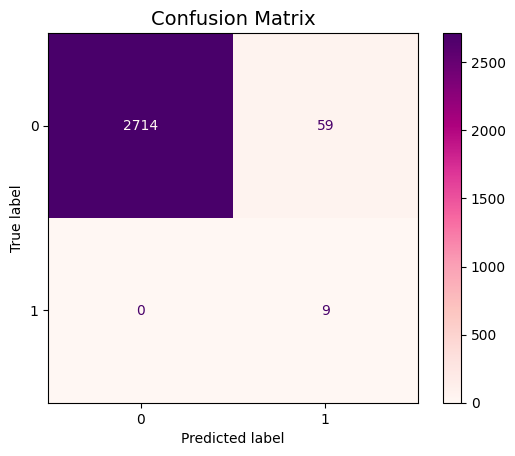

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="RdPu",
    values_format='d'
)

plt.title("Confusion Matrix", fontsize=14)
plt.show()

In [ ]:
print(classification_report(
    y_test,
    test_pred
))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      2773
         1.0       0.13      1.00      0.23         9

    accuracy                           0.98      2782
   macro avg       0.57      0.99      0.61      2782
weighted avg       1.00      0.98      0.99      2782

